In [28]:
from utils import *
import pandas as pd

In [29]:
df = pd.read_csv("../results/experiment_amgx_pcg.csv")
df = process_experiments_df(df)

In [30]:
def nice_solver_name(solver):
    if "CG_L1_" in solver:
        return "AmgX"

    prec = "fp64+fp32" if "float32" in solver else "fp64"
    matvec = "BSR" if "bsr_matmul=True" in solver else "CSR"
    return f"Our ({prec}, {matvec})"

In [31]:
df["best solve time"] = df["solve times"].apply(
    lambda times: min(times) if times else None
)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)
df["fine m val"] = df["fine m"].apply(lambda m: int(m[1:]))
df["nice solver"] = df["solver"].apply(nice_solver_name)

In [32]:
pivot = df.pivot_table(
    values="best DoFs/s", index=["p", "nice solver"], columns=["fine m val"]
)
pivot

fine m val                        1             2              3   \
p nice solver                                                       
1 AmgX                  15577.941670  44127.382191   69495.519676   
  Our (fp64+fp32, BSR)   2210.843717   5753.243652   17443.127752   
  Our (fp64+fp32, CSR)   3942.948276  10347.718205   29783.696845   
  Our (fp64, BSR)        2244.736103   5958.552421   17821.553069   
  Our (fp64, CSR)        4243.569723  10822.198477   31404.322009   
3 AmgX                  23125.665637  35261.675380  104894.649118   
  Our (fp64+fp32, BSR)   5041.399826   9266.621294   29974.312147   
  Our (fp64+fp32, CSR)   8938.499102  15947.335783   50531.591401   
  Our (fp64, BSR)        5206.359342   9487.179777   30547.317417   
  Our (fp64, CSR)        9468.154689  16480.085011   51908.209324   
5 AmgX                  26350.262660  52421.369739  150685.355555   
  Our (fp64+fp32, BSR)   6814.845373  15643.472466   54993.111609   
  Our (fp64+fp32, CSR)  11395.455112  27224.112769   90401.806335   
  Our (fp64, BSR)        7021.635919  16018.807832   53833.835057   
  Our (fp64, CSR)       12092.316360  28231.346995   91610.044585   

fine m val                         4             5             6   \
p nice solver                                                       
1 AmgX                  216605.526141  7.079725e+05  2.332064e+06   
  Our (fp64+fp32, BSR)   62785.888170  2.223339e+05  8.281225e+05   
  Our (fp64+fp32, CSR)  103700.602387  3.649378e+05  1.300835e+06   
  Our (fp64, BSR)        63478.882304  2.279776e+05  8.283869e+05   
  Our (fp64, CSR)       107620.425107  3.750081e+05  1.358590e+06   
3 AmgX                  347612.986655  1.247666e+06  2.832109e+06   
  Our (fp64+fp32, BSR)  109323.739528  4.205328e+05  1.386566e+06   
  Our (fp64+fp32, CSR)  180314.801225  6.749367e+05  2.109331e+06   
  Our (fp64, BSR)       107228.977208  4.019419e+05  1.342856e+06   
  Our (fp64, CSR)       184633.426906  6.761554e+05  1.967407e+06   
5 AmgX                  591669.107069  1.522075e+06  3.020172e+06   
  Our (fp64+fp32, BSR)  204799.627977  6.781631e+05  2.221993e+06   
  Our (fp64+fp32, CSR)  330639.984346  1.069664e+06  3.026470e+06   
  Our (fp64, BSR)       198400.859553  6.630426e+05  2.004275e+06   
  Our (fp64, CSR)       331538.155022  1.026689e+06  2.634687e+06   

fine m val                        7             8             9   \
p nice solver                                                      
1 AmgX                  6.689473e+06  1.493900e+07  2.434580e+07   
  Our (fp64+fp32, BSR)  2.659920e+06  9.263029e+06  2.486966e+07   
  Our (fp64+fp32, CSR)  4.337317e+06  1.285154e+07  2.921367e+07   
  Our (fp64, BSR)       2.621695e+06  8.723066e+06  2.033524e+07   
  Our (fp64, CSR)       4.197513e+06  1.182884e+07  2.282693e+07   
3 AmgX                  5.796471e+06  8.273429e+06  8.830991e+06   
  Our (fp64+fp32, BSR)  4.392311e+06  9.940189e+06  1.310609e+07   
  Our (fp64+fp32, CSR)  5.875282e+06  1.042583e+07  1.212738e+07   
  Our (fp64, BSR)       3.937126e+06  7.513103e+06  9.129696e+06   
  Our (fp64, CSR)       5.119050e+06  7.871058e+06  8.652938e+06   
5 AmgX                  4.508067e+06  4.908847e+06  4.812526e+06   
  Our (fp64+fp32, BSR)  5.157797e+06  7.342892e+06  7.766959e+06   
  Our (fp64+fp32, CSR)  5.467330e+06  6.697529e+06  6.695258e+06   
  Our (fp64, BSR)       4.026004e+06  5.142616e+06  5.266428e+06   
  Our (fp64, CSR)       4.260185e+06  4.832239e+06  4.753827e+06   

fine m val                        10            11  
p nice solver                                       
1 AmgX                  2.828594e+07  2.939712e+07  
  Our (fp64+fp32, BSR)  3.891844e+07  4.419564e+07  
  Our (fp64+fp32, CSR)  3.788544e+07  4.082324e+07  
  Our (fp64, BSR)       2.784155e+07  3.026317e+07  
  Our (fp64, CSR)       2.746943e+07  2.860941e+07  
3 AmgX                  8.854440e+06           NaN  
  Our (fp64+fp32, BSR)  1.396704e+07           NaN  
  Our (fp64+fp32, 

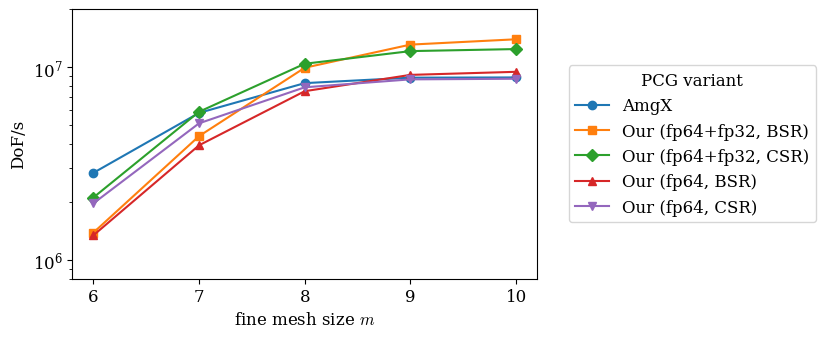

In [ ]:
p = 3
ms = [6, 7, 8, 9, 10]
data = pivot.xs(p, level="p")[ms]

fig, ax = plt.subplots(figsize=(6, 3.5))
markers = ["o", "s", "D", "^", "v", "P"]
for (solver, vals), marker in zip(data.iterrows(), markers):
    ax.plot(vals, label=solver, marker=marker)

ax.set_yscale("log")
ax.set_ylabel("DoF/s")
ax.set_ylim(8e5, 2e7)

ax.set_xlabel("fine mesh size $m$")
ax.set_xticks(ms)

ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", ncol=1, title="PCG variant")
fig.savefig("../docs/images/amgx_pcg_throughput.svg", bbox_inches="tight")